#Tourism Satellite Account Analysis of Japan (CY2023)
# 1. Introduction
###Notebook 01: Internal Tourism Consumption

This notebook provides a first look at Japan’s Tourism Satellite Account (TSA) for 2023.
The focus is on internal tourism consumption, including inbound tourism expenditure, domestic tourism expenditure, and other tourism consumption components.
The goal is to understand the size and structure of tourism demand in Japan.

1. Introduction
2. Data loading
3. Data cleaning
4. Tourism consumption ranking
5. Visualization
6. Inbound vs Domestic comparison
7. Tourism consumption structure
8. Key findings


# 2. Data loading

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

# 認証が完了すると、「drive/My Drive」以下にgoogle driveのルートがマウントされる。

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Google Drive path (for Colab)
file_path = "/content/drive/MyDrive/Data/tsa-analysis-Japan/data/JTA_TSA_2023.xlsx"
# file_path = "../data/JTA_TSA_2023.xlsx"  # for GitHub execution

xls = pd.ExcelFile(file_path)
# xls.sheet_names

In [ ]:
# Excel読込
df_table4 = pd.read_excel(file_path, sheet_name="Table4", header=4)

# 3. Data cleaning

In [ ]:
# 列名を付け直し
df_table4.columns = [
    "Code",
    "Products",
    "Inbound",
    "Domestic",
    "Internal_expenditure",
    "Other_components",
    "Internal_consumption",
    "Extra"
]

In [ ]:
# 上の説明行を落とす。その2行はデータではなく、「見出し」「番号説明」だから

df_table4 = df_table4.iloc[2:].reset_index(drop=True)

In [ ]:
# Products列に “Consumption products” を含む行を除外する、NaNはFalseとして扱う
df_table4 = df_table4[
    ~df_table4["Products"].str.contains("Consumption products", na=False)]

# Products列に “A.1. Tourism characteristic products” を含む行を除外する、NaNはFalseとして扱う
df_table4 = df_table4[
    ~df_table4["Products"].str.contains("A.1. Tourism characteristic products", na=False)]

# Products列に “A.2. Other consumption products” を含む行を除外する、NaNはFalseとして扱う
df_table4 = df_table4[
    ~df_table4["Products"].str.contains("A.2. Other consumption products", na=False)]

In [ ]:
# 文字列として入っている数値を、本物の数値に変換
## errors="coerce" は、数値にできないものを NaN にする、という指定
## たとえば X は数値ではないので NaN になる

for col in ["Inbound","Domestic","Internal_expenditure","Other_components","Internal_consumption"]:
    df_table4[col] = pd.to_numeric(df_table4[col], errors="coerce")

In [ ]:
# Code列,Extra列を削除
df_table4 = df_table4.drop(columns=["Code","Extra"])
print(df_table4.shape)

(27, 6)


In [ ]:
# 細分類を落とす（1.a や 1.b のような細かい枝番を除外する）
# 例.
## Accommodation services ... は残る
## 1.a. Accommodation services ... は消える
## 1.b. Vacation home ownership ... は消える

df_table4 = df_table4[
    ~df_table4["Products"].str.contains(r"\d+\.[a-z]", regex=True, na=False)
]

In [ ]:
# 改行をスペースに
df_table4["Products"] = df_table4["Products"].str.replace("\n", " ", regex=False)
df_table4.head(3)

,Products,Inbound,Domestic,Internal_expenditure,Other_components,Internal_consumption
2,1. Accommodation services for visitors 宿泊サービス,1877.0,4538.0,6415.0,487.0,6902.0
5,2. Food- and beverage-serving services 飲食サービス,1223.0,3168.0,4390.0,NaN,4390.0
6,3. Railway passenger transport services 鉄道旅客輸送...,424.0,2104.0,2528.0,NaN,2528.0


In [ ]:
# 除外するキーワード
exclude = [
    "Total",
    "tourism connected products",
    "non-tourism related consumption products"
]

pattern = "|".join(exclude)

df_table4 = df_table4[
    ~df_table4["Products"].str.contains(pattern, case=False, na=False)
]

# 4. Tourism consumption ranking

In [ ]:
top10 = df_table4.sort_values("Internal_consumption", ascending=False).head(10)

top10["Products_short"] = (
    top10["Products"]
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+[^\x00-\x7F]+.*$", "", regex=True)  # 日本語部分を削除
    .str.strip()
)

top10[["Products_short", "Internal_consumption"]].head(3)

,Products_short,Internal_consumption
2,1. Accommodation services for visitors,6902.0
5,2. Food- and beverage-serving services,4390.0
9,6. Air passenger transport services,2596.0


Internal tourism expenditure is defined as the sum of inbound tourism expenditure and domestic tourism expenditure.

Internal tourism consumption is larger than internal tourism expenditure because it also includes other components of tourism consumption.

# 5. Visualization

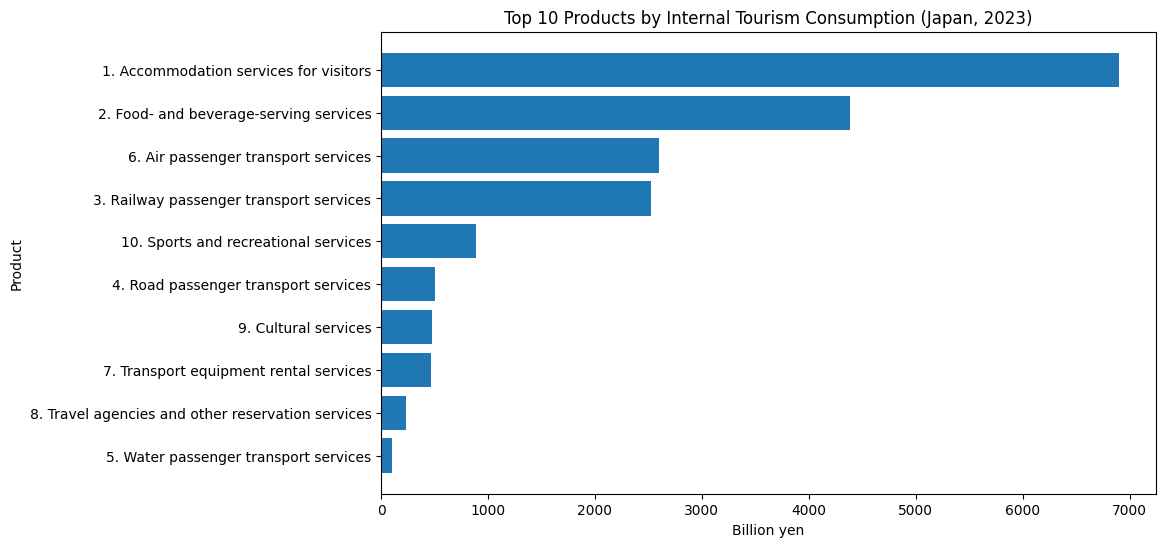

In [ ]:
# Top 10 Products by Internal Tourism Consumption (Japan, 2023)
plt.figure(figsize=(10, 6))
plt.barh(top10["Products_short"], top10["Internal_consumption"])
plt.gca().invert_yaxis()
plt.title("Top 10 Products by Internal Tourism Consumption (Japan, 2023)")
plt.xlabel("Billion yen")
plt.ylabel("Product")
plt.show()

# 6. Inbound vs Domestic comparison

In [ ]:
# 旅行支出全体に伴うインバウンド支出の割合等
df_table4["Inbound_share"] = df_table4["Inbound"] / df_table4["Internal_consumption"]
df_table4["Domestic_share"] = df_table4["Domestic"] / df_table4["Internal_consumption"]

df_table4.head()

,Products,Inbound,Domestic,Internal_expenditure,Other_components,Internal_consumption,Inbound_share,Domestic_share
2,1. Accommodation services for visitors 宿泊サービス,1877.0,4538.0,6415.0,487.0,6902.0,0.271950,0.657491
5,2. Food- and beverage-serving services 飲食サービス,1223.0,3168.0,4390.0,NaN,4390.0,0.278588,0.721640
6,3. Railway passenger transport services 鉄道旅客輸送...,424.0,2104.0,2528.0,NaN,2528.0,0.167722,0.832278
7,4. Road passenger transport services 道路旅客輸送サービス,95.0,413.0,507.0,NaN,507.0,0.187377,0.814596
8,5. Water passenger transport services 水運旅客輸送サービス,3.0,95.0,98.0,NaN,98.0,0.030612,0.969388


In [ ]:
# 外国人依存ランキング
df_table4.sort_values("Inbound_share", ascending=False)[
    ["Products","Inbound_share"]
].head(10)

,Products,Inbound_share
22,B.1. Valuables 貴重品,1.000000
21,B. Non-consumption products 非消費商品,1.000000
5,2. Food- and beverage-serving services 飲食サービス,0.278588
2,1. Accommodation services for visitors 宿泊サービス,0.271950
9,6. Air passenger transport services 航空旅客輸送サービス,0.208012
7,4. Road passenger transport services 道路旅客輸送サービス,0.187377
6,3. Railway passenger transport services 鉄道旅客輸送...,0.167722
10,7. Transport equipment rental services 輸送機器レンタ...,0.153846
11,8. Travel agencies and other reservation servi...,0.126087
12,9. Cultural services 文化サービス,0.106918


In [ ]:
# Domestic依存ランキング
df_table4.sort_values("Domestic_share", ascending=False)[
    ["Products","Domestic_share"]
].head(10)

,Products,Domestic_share
8,5. Water passenger transport services 水運旅客輸送サービス,0.969388
13,10. Sports and recreational services スポーツ及びレクリ...,0.895740
12,9. Cultural services 文化サービス,0.893082
11,8. Travel agencies and other reservation servi...,0.869565
10,7. Transport equipment rental services 輸送機器レンタ...,0.848291
6,3. Railway passenger transport services 鉄道旅客輸送...,0.832278
7,4. Road passenger transport services 道路旅客輸送サービス,0.814596
9,6. Air passenger transport services 航空旅客輸送サービス,0.791988
5,2. Food- and beverage-serving services 飲食サービス,0.721640
2,1. Accommodation services for visitors 宿泊サービス,0.657491


# 7. Tourism consumption structure

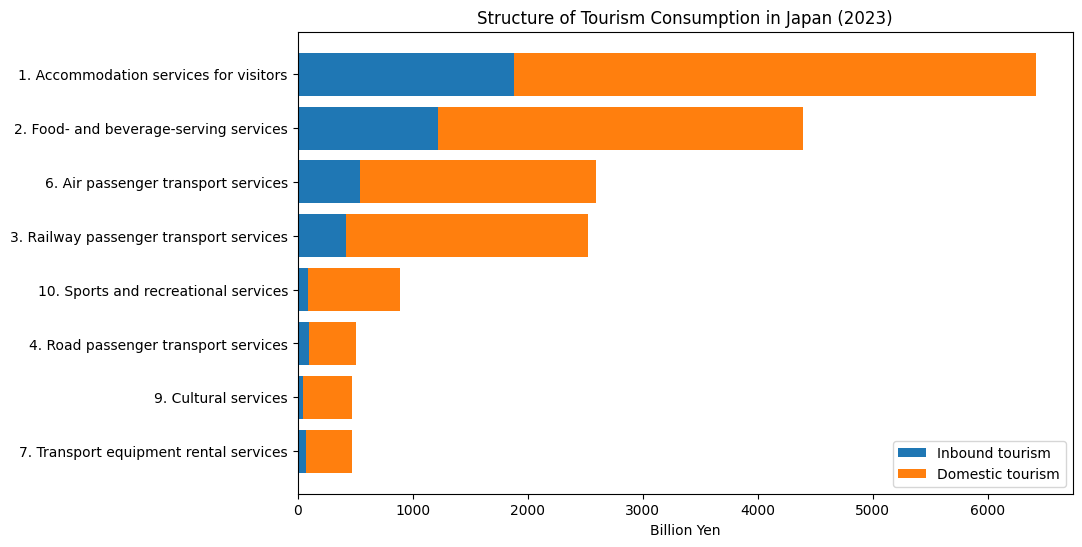

In [ ]:
# Stacked chart（構造可視化）
top8 = df_table4.sort_values(
    "Internal_consumption",
    ascending=False
).head(8)

top8["Products_short"] = (
    top8["Products"]
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+[^\x00-\x7F]+.*$", "", regex=True)  # 日本語部分を削除
    .str.strip()
)

plt.figure(figsize=(10,6))

plt.barh(
    top8["Products_short"],
    top8["Inbound"],
    label="Inbound tourism"
)

plt.barh(
    top8["Products_short"],
    top8["Domestic"],
    left=top8["Inbound"],
    label="Domestic tourism"
)

plt.gca().invert_yaxis()

plt.xlabel("Billion Yen")
plt.title("Structure of Tourism Consumption in Japan (2023)")

plt.legend()

plt.show()

### Tourism consumption structure

The stacked bar chart shows the composition of tourism consumption by product.

Domestic tourism accounts for the majority of spending across most tourism products.
However, inbound tourism still represents a significant share in several sectors.

Food and beverage serving services and Accommodation services show a relatively higher share of inbound tourism compared with other sectors.

This indicates that international visitors contribute substantially to the hospitality and transportation industries in Japan.

### 8. Key Findings

Accommodation services represent the largest component of tourism consumption in Japan in 2023.

Food and beverage services also account for a substantial share of tourism demand.
Together with accommodation services, they indicate that a large portion of tourism spending is concentrated in the hospitality sector.

Passenger transport services, including air transport and railway transport, also represent significant components of tourism consumption.

These results suggest that tourism spending in Japan is strongly concentrated in three sectors:
accommodation, food services, and transportation.